# AttoPython Examples

This notebook consolidates the standalone `Run*` / `Plot_*` / `Calc_*` scripts that used to live alongside the helper classes in `Source/` and `MLexamples/`. Each section below uses the relevant helper class(es) to reproduce what the original script did.

**Run the setup cell first** — it makes sure the working directory is the repository root (so the relative `/Data/...` paths used by the helper classes resolve correctly) and that `Source`/`MLexamples` can be imported as top-level packages.

All of the examples in this notebook run out-of-the-box using the sample data already included in this repository. For examples that need extra data not included here (an MNIST download, ARC job output), see `examples.ipynb`.

In [7]:
import os
import sys

# Ensure the working directory is the repository root so that the relative
# data paths used throughout AttoPython (e.g. "/Data/...") resolve correctly,
# and so "Source"/"MLexamples" can be imported as top-level packages.
if os.path.basename(os.getcwd()) == "notebooks":
    os.chdir(os.path.dirname(os.getcwd()))

REPO_ROOT = os.getcwd()
if REPO_ROOT not in sys.path:
    sys.path.insert(0, REPO_ROOT)

print("Working directory:", os.getcwd())

Working directory: /home/vscode/AttoPython


## 1. Contour plotting

From `Source/Plotters/ContourPlot/Plot_Contour.py`. Loads and plots a 2D amplitude grid using `ContourDataHelper` + `BasePlotter`, using the sample amplitude grid included under `Data/140603.10/Data/`.

In [ ]:
from Source.Plotters.ContourPlot.ContourDataHelper import ContourDataHelper
from Source.Base.BasePlotter import BasePlotter

xRange, yRange = 500, 400
_min, _max = 1e-4, 1e-1
path = "/Data/"
filename = "Amplitude_Grid_w2_3_10_phi_0.9_500X400.dat"

dataHelper = ContourDataHelper(path=path, filename=filename, x_range=xRange, y_range=yRange, min=_min, max=_max)
dataHelper.load_to_array()
dataHelper.create_array(7)
dataHelper.normalise()

plotter = BasePlotter(dataHelper)
plotter.PlotColourMesh()

## 2. Trajectory scatter plots

From `Source/Plotters/Plot_Trajectories.py`. Plots initial vs. final momentum scatter plots using `TrajDataHelper` + `BasePlotter`.

Loading to array....
plotting scatter plot


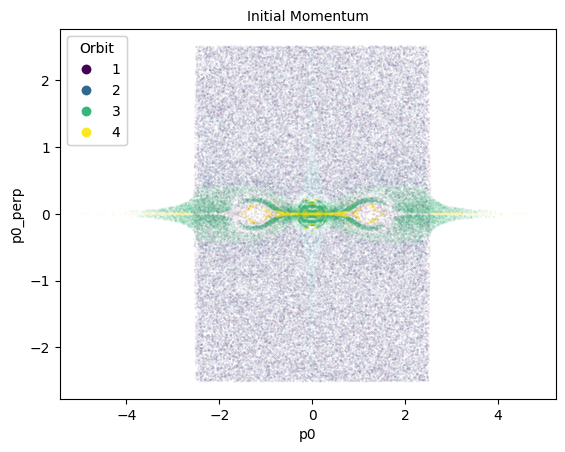

plotting scatter plot


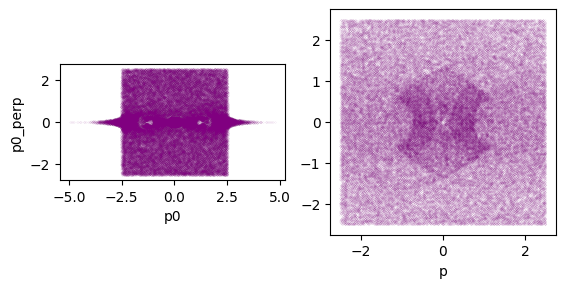

Done


In [ ]:
from Source.Base.BasePlotter import BasePlotter
from Source.Plotters.TrajDataHelper import TrajDataHelper

path = "/Data/"
filename = "Binned_Initial_Condition_Grid_trunc1"
helper = TrajDataHelper(path, filename)
print("Loading to array....")
helper.load_to_array()
helper.create_data_frame()
helper.AssignColumnNames()

print("plotting scatter plot")
plotter = BasePlotter(helper)
plotter.plotScatter(helper.p0, helper.p0_perp, "Initial Momentum", 10)

print("plotting scatter plot")
plotter = BasePlotter(helper)
plotter.plot2Scatter(
    helper.p0, helper.p0_perp, helper.pf, helper.pf_perp, "Initial Momentum", 10
)
print("Done")

## 3. Orbit classification models

From `Source/MachineLearning/Regression/RunREgression.py`. Compares `DecisionTreeClassifier` and `ExtraTreeClassifier` on trajectory orbit data via `ModelAnalyser`.

In [ ]:
from sklearn.tree import DecisionTreeClassifier, ExtraTreeClassifier
from Source.Plotters.TrajDataHelper import TrajDataHelper
from Source.MachineLearning.Regression.ModelAnalyser import ModelAnalyser
from Source.MachineLearning.Regression.ModelAnalyserIO import ModelAnalyserIO

path = "/Data/"
filename = "Binned_Initial_Condition_Grid_trunc"
helper = TrajDataHelper(path, filename)
print("Loading to array....")
helper.load_to_array()
helper.create_data_frame()
helper.AssignColumnNames()

print("Running Analyser....")
models = [DecisionTreeClassifier(), ExtraTreeClassifier()]
testSize = 0.25
analyser = ModelAnalyser(helper, models, testSize)
analyser.CompareModels()

print("Output Results...")
analyserIO = ModelAnalyserIO(analyser)
analyserIO.printDataStructureToScreen()
analyserIO.printModelPerformanceToScreen()

Loading to array....
Running Analyser....
Output Results...
Initial Columns :  p0 p0_perp t0_re t0_im z0 p p_perp orbit rf rf_perp stability guoy
Target Columns :  orbit
Dropped Columns :  orbit p0 p
Model : DecisionTreeClassifier
      precision : 1.0
      accuracy : 1.0
      sensitivity : 1.0
      specificity : 1.0
Model : ExtraTreeClassifier
      precision : 1.0
      accuracy : 1.0
      sensitivity : 1.0
      specificity : 1.0


## 4. Clustering

From `Source/MachineLearning/Clustering/RunClustering.py`. Runs a DBSCAN parameter search over trajectory orbit clusters using `ClusteringHelper`.

In [13]:
import copy
from Source.MachineLearning.Clustering.ClusteringHelper import ClusteringHelper
from Source.MachineLearning.Clustering.GlobalClusteringFunctions import (
    LoopClusteringParams,
    PlotResults,
    CreateHelpersForOrbits,
)

path = "/Data/"
filename = "Binned_Initial_Condition_Grid_trunc1"
coreHelper = ClusteringHelper(path, filename)

print("Loading Data " + filename + " ..... ")
coreHelper.load_to_array()
coreHelper.create_data_frame()
coreHelper.AssignColumnNames()

MLhelper = copy.deepcopy(coreHelper)
MLhelper.Truncate(100000)
MLhelper.path = MLhelper.path + "Clustering/"

# Variables for the clustering parameter search
minEps, maxEps = 0.01, 3
minSamples, maxSamples = 25, 125
maxRange = 30

MLhelpers = CreateHelpersForOrbits(MLhelper)
for i, helper in enumerate(MLhelpers):
    if i < 2:
        continue
    orbit = "All" if i == 0 else str(i)
    minClusters, maxClusters = (4, 5) if i == 0 else (2, 4)
    print("Running Clustering orbit " + orbit)
    helpers = LoopClusteringParams(
        helper, minSamples, maxSamples, minEps, maxEps, minClusters, maxClusters, maxRange
    )
    print("Plotting .....")
    PlotResults(helpers, orbit)

Loading Data Binned_Initial_Condition_Grid_trunc1 ..... 
Running Clustering orbit 2
i = 1 of 30
Cluster fits criteria 
i = 2 of 30
Cluster fits criteria 
i = 3 of 30
Cluster fits criteria 
i = 4 of 30
Cluster fits criteria 
i = 5 of 30
Cluster fits criteria 
i = 6 of 30
i = 7 of 30
Cluster fits criteria 
i = 8 of 30
Cluster fits criteria 
i = 9 of 30
Cluster fits criteria 
i = 10 of 30
Cluster fits criteria 
i = 11 of 30
Cluster fits criteria 
i = 12 of 30
Cluster fits criteria 
i = 13 of 30
Cluster fits criteria 
i = 14 of 30
Cluster fits criteria 
i = 15 of 30
Cluster fits criteria 
i = 16 of 30
Cluster fits criteria 
i = 17 of 30
Cluster fits criteria 
i = 18 of 30
Cluster fits criteria 
i = 19 of 30
Cluster fits criteria 
i = 20 of 30
Cluster fits criteria 
i = 21 of 30
i = 22 of 30
Cluster fits criteria 
i = 23 of 30
Cluster fits criteria 
i = 24 of 30
Cluster fits criteria 
i = 25 of 30
Cluster fits criteria 
i = 26 of 30
i = 27 of 30
Cluster fits criteria 
i = 28 of 30
i = 29 of

## 5. IRIS linear regression

From `MLexamples/Regression/IRIS/PredictIRIS.py`. Fits a `LinearRegression` model to predict sepal length from the other IRIS features.

['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']


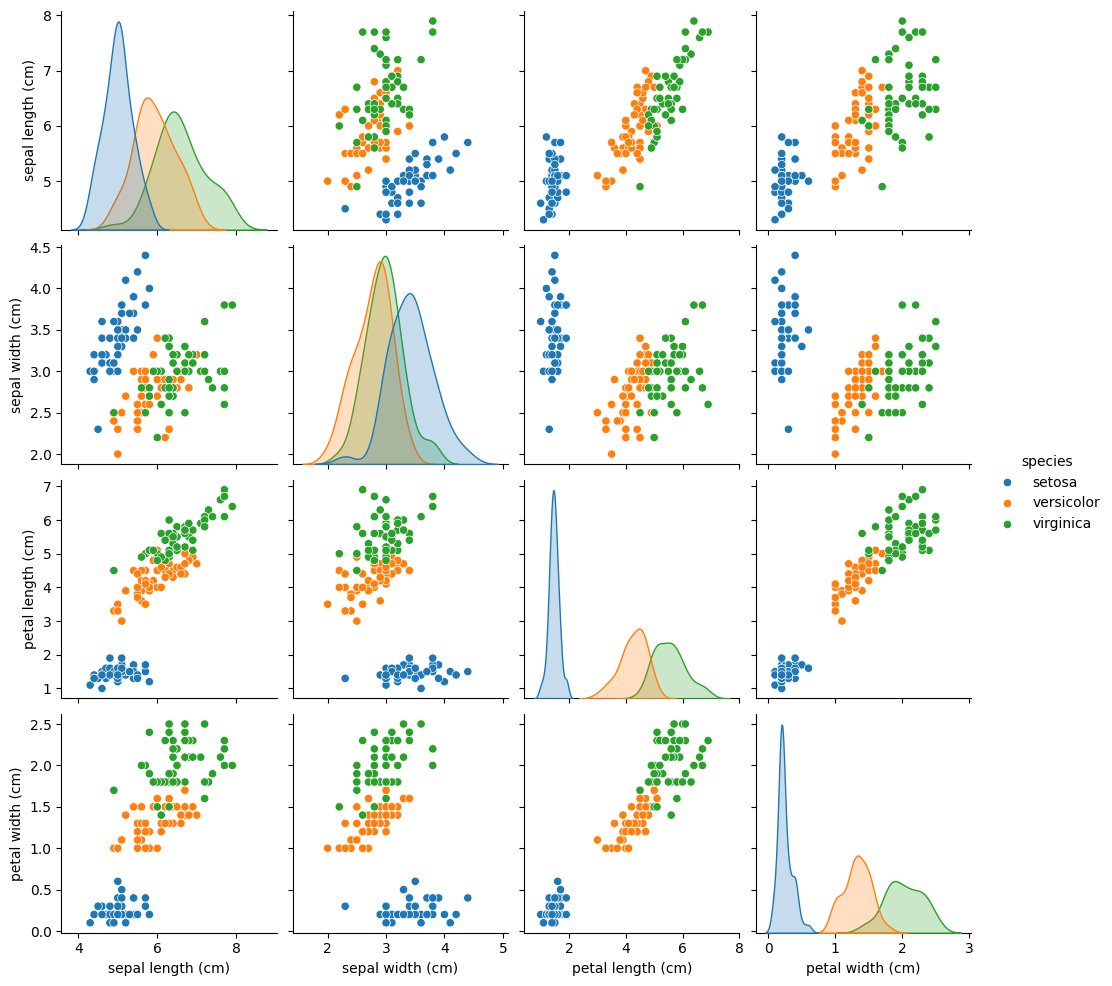

predicted length = 5.491579724105749 ### actual length = 5.5
predicted length = 5.073091023703226 ### actual length = 5.4
predicted length = 4.893665901547918 ### actual length = 5.0
predicted length = 7.070667284444565 ### actual length = 7.2
predicted length = 6.503377141506917 ### actual length = 7.0
predicted length = 6.039757373248348 ### actual length = 6.3
predicted length = 5.608554083509968 ### actual length = 6.2
predicted length = 5.4334328215179575 ### actual length = 5.5
predicted length = 5.911768486496087 ### actual length = 6.3
predicted length = 4.685815398310169 ### actual length = 4.9
predicted length = 6.330361441140462 ### actual length = 6.5
predicted length = 5.571232832107538 ### actual length = 5.2
predicted length = 4.8904611906534905 ### actual length = 5.4
predicted length = 7.344357157079373 ### actual length = 7.7
predicted length = 6.241198454697243 ### actual length = 6.1
predicted length = 6.065972938463383 ### actual length = 6.4
predicted length = 5.9

In [11]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from MLexamples.Regression.IRIS.IRISclass import IRISclass

iris = IRISclass()
iris.plotIRISdata()

X = iris.df.drop(labels="sepal length (cm)", axis=1)
y = iris.df["sepal length (cm)"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.33, random_state=101)

lr = LinearRegression()
lr.fit(X_train, y_train)
predictions = lr.predict(X_test)

iris.PrintPerformanceInfo(predictions, y_test)